# Analisis tambahan — hs-CRP IFLS-5 (untuk naskah ORCP)

Notebook ini melengkapi `model_crp_ifls5.ipynb` dan mengisi semua tanda **[Add …]** di naskah:

1. **Validasi silang berulang** (5-fold × beberapa ulangan) untuk semua model, dengan dua skema: acak per orang dan **dikelompokkan per rumah tangga** (anggota satu rumah tangga tidak pernah terpisah antara data latih dan data uji).
2. **Regresi logistik dengan SE klaster per rumah tangga** (cluster-robust, CR1).
3. **Rekalibrasi** (Platt dan isotonik) dengan intersep dan kemiringan kalibrasi.
4. **Analisis sensitivitas**: (a) peserta CRP > 10 mg/L tetap disertakan, (b) model tanpa *kesehatan dirasa buruk*, (c) perbandingan peserta yang dikeluarkan vs yang dianalisis, (d) OR merokok per jenis kelamin.

Hyperparameter memakai hasil tuning terbaik dari notebook utama, sehingga notebook ini tidak melakukan tuning ulang. Semua hasil tersimpan di `results/analisis_tambahan.xlsx`.

In [1]:
# === SEL 0: folder kerja dan file data ===
import os
ROOT = r"F:\SINTA 3\crp-ifls5-ml"
OUTDIR = os.path.join(ROOT, "results")
os.makedirs(OUTDIR, exist_ok=True)
os.chdir(OUTDIR)
DATA_FILE = os.path.join(ROOT, "data", "crp_ifls5_model.csv")
ANALYTIC_FILE = r"F:\SINTA 3\olahan_ifls5\ifls5_analytic.csv"   # untuk analisis CRP > 10 dan perbandingan peserta dikeluarkan
assert os.path.exists(DATA_FILE), f"Data tidak ditemukan: {DATA_FILE}"
print("Folder kerja :", os.getcwd())
print("Data model   :", DATA_FILE)
print("Data analitik:", ANALYTIC_FILE, "(ada)" if os.path.exists(ANALYTIC_FILE) else "(TIDAK ADA - analisis 4a dan 4c dilewati)")

# Jumlah ulangan validasi silang. 5 = cukup untuk naskah (sekitar 30-60 menit dengan DNN). Naikkan ke 10 bila ada waktu.
REPEATS = 5
RUN_DNN = True

Folder kerja : F:\SINTA 3\crp-ifls5-ml\results
Data model   : F:\SINTA 3\crp-ifls5-ml\data\crp_ifls5_model.csv
Data analitik: F:\SINTA 3\olahan_ifls5\ifls5_analytic.csv (ada)


In [2]:
import warnings, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from scipy import stats
from sklearn.model_selection import (train_test_split, StratifiedKFold, StratifiedGroupKFold, RepeatedStratifiedKFold,
                                     cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.base import clone, BaseEstimator, ClassifierMixin

def ada(m):
    try: __import__(m); return True
    except ImportError: return False
HAS_XGB, HAS_LGBM, HAS_TORCH = ada('xgboost'), ada('lightgbm'), ada('torch')
MODE = 'FINAL' if (HAS_XGB and HAS_LGBM) else 'PRATINJAU'
print(f'XGBoost={HAS_XGB} | LightGBM={HAS_LGBM} | PyTorch={HAS_TORCH} | MODE: {MODE}')
SEED = 42

XGBoost=True | LightGBM=True | PyTorch=True | MODE: FINAL


In [3]:
df = pd.read_csv(DATA_FILE, dtype={'pidlink': str, 'hhid14': str})
NUM = ['age', 'lnpce', 'hhsize', 'cig_day', 'pa_vig_days', 'pa_mod_days', 'pa_walk_days', 'bmi', 'sbp', 'dbp', 'n_chronic', 'cesd10']
BIN = ['female', 'married', 'widowed', 'urban', 'dx_hypert', 'dx_diab', 'dx_heart', 'dx_stroke', 'dx_chol',
       'dx_asthma', 'dx_lung', 'dx_arthritis', 'dx_kidney', 'dx_liver', 'dx_digest', 'med_hypert', 'med_diab', 'srh_poor']
CAT = ['educ', 'smoke_status']
FEATS = NUM + BIN + CAT
X, y, groups = df[FEATS].copy(), df.crp_high.values, df.hhid14.values

# Pembagian latih/uji IDENTIK dengan notebook utama (seed 42, stratified)
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(X, y, df.index, test_size=0.2, stratify=y, random_state=SEED)
hh_tr, hh_te = set(df.loc[idx_tr, 'hhid14']), df.loc[idx_te, 'hhid14']
shared = hh_te.isin(hh_tr)
n_hh = df.hhid14.nunique(); size = df.groupby('hhid14').size()
print(f'n = {len(df)}, kasus = {y.sum()} ({y.mean()*100:.1f}%) | rumah tangga = {n_hh}; '
      f'{(size > 1).sum()} rumah tangga punya >1 peserta ({size[size > 1].sum()} peserta)')
print(f'Data uji: {shared.sum()} dari {len(idx_te)} peserta ({shared.mean()*100:.1f}%) punya anggota rumah tangga di data latih')

def prep(scale, feats=FEATS):
    num, bin_, cat = [c for c in NUM if c in feats], [c for c in BIN if c in feats], [c for c in CAT if c in feats]
    num_steps = [('imp', SimpleImputer(strategy='median'))] + ([('sc', StandardScaler())] if scale else [])
    return ColumnTransformer([('num', Pipeline(num_steps), num), ('bin', SimpleImputer(strategy='most_frequent'), bin_),
                              ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                                                ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat)],
                             verbose_feature_names_out=False)

n = 5980, kasus = 904 (15.1%) | rumah tangga = 3655; 1505 rumah tangga punya >1 peserta (3830 peserta)
Data uji: 686 dari 1196 peserta (57.4%) punya anggota rumah tangga di data latih


In [4]:
# === Model dengan hyperparameter terbaik dari notebook utama ===
class BalancedMLP(MLPClassifier):
    def fit(self, X, y, sample_weight=None):
        return super().fit(X, y, sample_weight=compute_sample_weight('balanced', y))

if HAS_TORCH:
    import torch, torch.nn as nn
    class TorchDNN(ClassifierMixin, BaseEstimator):
        def __init__(self, hidden=(64, 32), dropout=0.3, lr=1e-3, weight_decay=1e-5, epochs=300, batch=128, patience=25, seed=SEED):
            self.hidden, self.dropout, self.lr, self.weight_decay = hidden, dropout, lr, weight_decay
            self.epochs, self.batch, self.patience, self.seed = epochs, batch, patience, seed
        def _net(self, d):
            layers = []
            for h in self.hidden: layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(self.dropout)]; d = h
            return nn.Sequential(*layers, nn.Linear(d, 1))
        def fit(self, X, y):
            torch.manual_seed(self.seed); X = np.asarray(X, np.float32); y = np.asarray(y, np.float32)
            self.classes_ = np.array([0, 1])
            Xa, Xv, ya, yv = train_test_split(X, y, test_size=0.15, stratify=y, random_state=self.seed)
            self.net_ = self._net(X.shape[1]); opt = torch.optim.AdamW(self.net_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
            lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(float((ya == 0).sum() / (ya == 1).sum())))
            Xa_t, ya_t, Xv_t = torch.tensor(Xa), torch.tensor(ya), torch.tensor(Xv)
            best, wait, state = -1, 0, None
            for ep in range(self.epochs):
                self.net_.train(); perm = torch.randperm(len(Xa_t))
                for i in range(0, len(perm), self.batch):
                    b = perm[i:i + self.batch]
                    if len(b) < 2: continue
                    opt.zero_grad(); lossf(self.net_(Xa_t[b]).squeeze(1), ya_t[b]).backward(); opt.step()
                self.net_.eval()
                with torch.no_grad(): auc = roc_auc_score(yv, self.net_(Xv_t).squeeze(1).numpy())
                if auc > best: best, wait, state = auc, 0, {k: v.clone() for k, v in self.net_.state_dict().items()}
                else:
                    wait += 1
                    if wait >= self.patience: break
            self.net_.load_state_dict(state); return self
        def predict_proba(self, X):
            self.net_.eval()
            with torch.no_grad(): p = torch.sigmoid(self.net_(torch.tensor(np.asarray(X, np.float32))).squeeze(1)).numpy()
            return np.c_[1 - p, p]
        def predict(self, X): return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

POS_W = (y_tr == 0).sum() / (y_tr == 1).sum()      # sama dengan notebook utama (5,62)
if HAS_XGB: from xgboost import XGBClassifier

def make_models(feats=FEATS):
    M = {}
    M['Logistic regression'] = Pipeline([('p', prep(True, feats)), ('m', LogisticRegression(C=0.011288378916846888, class_weight='balanced', max_iter=3000))])
    M['Random forest'] = Pipeline([('p', prep(False, feats)), ('m', RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=40,
                                   max_features='sqrt', class_weight='balanced_subsample', n_jobs=-1, random_state=SEED))])
    if HAS_XGB:
        M['XGBoost'] = Pipeline([('p', prep(False, feats)), ('m', XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.01, subsample=0.85, colsample_bytree=0.8,
                                 min_child_weight=10, scale_pos_weight=POS_W, eval_metric='logloss', n_jobs=-1, random_state=SEED))])
    else:
        M['HistGB (pengganti XGBoost)'] = Pipeline([('p', prep(False, feats)), ('m', HistGradientBoostingClassifier(class_weight='balanced', max_iter=200,
                                                   learning_rate=0.03, max_leaf_nodes=7, random_state=SEED))])
    if HAS_LGBM:
        from lightgbm import LGBMClassifier
        M['LightGBM'] = Pipeline([('p', prep(False, feats)), ('m', LGBMClassifier(n_estimators=200, num_leaves=15, learning_rate=0.01, min_child_samples=50,
                                  subsample=0.7, colsample_bytree=0.6, class_weight='balanced', random_state=SEED, verbose=-1))])
    M['MLP'] = Pipeline([('p', prep(True, feats)), ('m', BalancedMLP(hidden_layer_sizes=(64, 32), alpha=1.0, learning_rate_init=0.003, batch_size=64,
                         early_stopping=True, validation_fraction=0.15, n_iter_no_change=20, max_iter=600, random_state=SEED))])
    if HAS_TORCH and RUN_DNN:
        M['DNN (PyTorch)'] = Pipeline([('p', prep(True, feats)), ('m', TorchDNN())])
    M['Ensemble (RF + MLP + LR)'] = VotingClassifier([('rf', clone(M['Random forest'])), ('mlp', clone(M['MLP'])),
                                                      ('lr', clone(M['Logistic regression']))], voting='soft')
    return M

MODELS = make_models()
print('Model:', list(MODELS))

Model: ['Logistic regression', 'Random forest', 'XGBoost', 'LightGBM', 'MLP', 'DNN (PyTorch)', 'Ensemble (RF + MLP + LR)']


## 1. Validasi silang berulang (acak per orang vs dikelompokkan per rumah tangga)
Untuk setiap fold dihitung AUC, AUC-PR, Brier, dan sensitivitas pada spesifisitas tetap 0,70 dan 0,80. Selisih AUC tiap model terhadap ensemble diuji dengan *corrected resampled t-test* (Nadeau & Bengio, 2003), yang mengoreksi korelasi antar-fold.

In [5]:
def sens_at_spec(yt, p, spec):
    f, t, _ = roc_curve(yt, p); return t[f <= 1 - spec].max()

def run_cv(scheme):
    rows = []
    for r in range(REPEATS):
        if scheme == 'household':
            splits = StratifiedGroupKFold(5, shuffle=True, random_state=SEED + r).split(X, y, groups)
        else:
            splits = StratifiedKFold(5, shuffle=True, random_state=SEED + r).split(X, y)
        for k, (tr, te) in enumerate(splits):
            for name, m in MODELS.items():
                t0 = time.time(); mm = clone(m).fit(X.iloc[tr], y[tr]); p = mm.predict_proba(X.iloc[te])[:, 1]
                rows.append({'scheme': scheme, 'repeat': r, 'fold': k, 'model': name, 'n_train': len(tr), 'n_test': len(te),
                             'AUC': roc_auc_score(y[te], p), 'AUC-PR': average_precision_score(y[te], p), 'Brier': brier_score_loss(y[te], p),
                             'Sens@Spec0.70': sens_at_spec(y[te], p, 0.70), 'Sens@Spec0.80': sens_at_spec(y[te], p, 0.80),
                             'sec': time.time() - t0})
        print(f'{scheme}: ulangan {r + 1}/{REPEATS} selesai')
    return pd.DataFrame(rows)

t0 = time.time()
cv_folds = pd.concat([run_cv('individual'), run_cv('household')], ignore_index=True)
print(f'Selesai dalam {(time.time() - t0) / 60:.1f} menit')

individual: ulangan 1/5 selesai
individual: ulangan 2/5 selesai
individual: ulangan 3/5 selesai
individual: ulangan 4/5 selesai
individual: ulangan 5/5 selesai
household: ulangan 1/5 selesai
household: ulangan 2/5 selesai
household: ulangan 3/5 selesai
household: ulangan 4/5 selesai
household: ulangan 5/5 selesai
Selesai dalam 16.4 menit


In [6]:
def summarize(d):
    g = d.groupby(['scheme', 'model'])
    s = g[['AUC', 'AUC-PR', 'Brier', 'Sens@Spec0.70', 'Sens@Spec0.80']].agg(['mean', 'std'])
    s.columns = [f'{a} {b}' for a, b in s.columns]
    s['AUC 2.5%'] = g.AUC.quantile(0.025); s['AUC 97.5%'] = g.AUC.quantile(0.975); s['folds'] = g.size()
    return s.round(3).reset_index().sort_values(['scheme', 'AUC mean'], ascending=[True, False])

def corrected_ttest(d, ref='Ensemble (RF + MLP + LR)'):
    out = []
    for scheme, ds in d.groupby('scheme'):
        piv = ds.pivot_table(index=['repeat', 'fold'], columns='model', values='AUC')
        n_te, n_tr = ds.n_test.mean(), ds.n_train.mean(); J = len(piv)
        for m in piv.columns:
            if m == ref: continue
            diff = (piv[m] - piv[ref]).values; mu, var = diff.mean(), diff.var(ddof=1)
            se = np.sqrt((1 / J + n_te / n_tr) * var); tval = mu / se if se > 0 else np.nan
            out.append({'scheme': scheme, 'model': m, 'reference': ref, 'mean AUC difference': mu,
                        '95% CI low': mu - stats.t.ppf(0.975, J - 1) * se, '95% CI high': mu + stats.t.ppf(0.975, J - 1) * se,
                        'p (corrected t-test)': 2 * stats.t.sf(abs(tval), J - 1), 'folds where model > reference': (diff > 0).mean()})
    return pd.DataFrame(out).round(4)

cv_summary, cv_diff = summarize(cv_folds), corrected_ttest(cv_folds)
display(cv_summary); display(cv_diff)

,scheme,model,AUC mean,AUC std,AUC-PR mean,AUC-PR std,Brier mean,Brier std,Sens@Spec0.70 mean,Sens@Spec0.70 std,Sens@Spec0.80 mean,Sens@Spec0.80 std,AUC 2.5%,AUC 97.5%,folds
6,household,XGBoost,0.686,0.025,0.315,0.028,0.217,0.002,0.574,0.040,0.455,0.030,0.635,0.730,25
1,household,Ensemble (RF + MLP + LR),0.681,0.025,0.308,0.031,0.216,0.005,0.563,0.039,0.452,0.027,0.632,0.729,25
2,household,LightGBM,0.681,0.026,0.309,0.030,0.212,0.003,0.569,0.038,0.447,0.040,0.624,0.727,25
5,household,Random forest,0.680,0.025,0.309,0.028,0.205,0.002,0.555,0.042,0.451,0.041,0.629,0.729,25
4,household,MLP,0.677,0.024,0.305,0.028,0.224,0.013,0.558,0.041,0.444,0.033,0.630,0.718,25
0,household,DNN (PyTorch),0.675,0.024,0.306,0.029,0.223,0.008,0.538,0.038,0.426,0.035,0.622,0.709,25
3,household,Logistic regression,0.675,0.026,0.292,0.027,0.223,0.003,0.564,0.041,0.444,0.030,0.627,0.725,25
13,individual,XGBoost,0.684,0.015,0.314,0.018,0.217,0.003,0.573,0.028,0.451,0.030,0.659,0.711,25
8,individual,Ensemble (RF + MLP + LR),0.681,0.016,0.308,0.023,0.215,0.005,0.563,0.025,0.448,0.032,0.658,0.711,25
11,individual,MLP,0.678,0.016,0.304,0.022,0.219,0.014,0.560,0.031,0.447,0.031,0.655,0.710,25


,scheme,model,reference,mean AUC difference,95% CI low,95% CI high,p (corrected t-test),folds where model > reference
0,household,DNN (PyTorch),Ensemble (RF + MLP + LR),-0.0061,-0.0171,0.0048,0.2609,0.24
1,household,LightGBM,Ensemble (RF + MLP + LR),0.0003,-0.0078,0.0084,0.9447,0.52
2,household,Logistic regression,Ensemble (RF + MLP + LR),-0.0063,-0.0096,-0.0029,0.0008,0.00
3,household,MLP,Ensemble (RF + MLP + LR),-0.0041,-0.0082,-0.0000,0.0477,0.08
4,household,Random forest,Ensemble (RF + MLP + LR),-0.0007,-0.0054,0.0040,0.7550,0.36
5,household,XGBoost,Ensemble (RF + MLP + LR),0.0051,-0.0050,0.0152,0.3053,0.76
6,individual,DNN (PyTorch),Ensemble (RF + MLP + LR),-0.0074,-0.0187,0.0039,0.1902,0.28
7,individual,LightGBM,Ensemble (RF + MLP + LR),-0.0032,-0.0141,0.0076,0.5438,0.40
8,individual,Logistic regression,Ensemble (RF + MLP + LR),-0.0063,-0.0103,-0.0023,0.0034,0.04
9,individual,MLP,Ensemble (RF + MLP + LR),-0.0026,-0.0066,0.0014,0.1878,0.20


## 2. Regresi logistik dengan SE klaster per rumah tangga
Model dan prediktor sama dengan Tabel 2 di naskah. SE biasa (berbasis model) dibandingkan dengan SE klaster (sandwich CR1, klaster = rumah tangga).

In [7]:
def design(d):
    R = pd.DataFrame({
        'BMI (per 5 kg/m²)': d.bmi / 5, 'Age (per 10 years)': d.age / 10, 'Female sex': d.female,
        'Urban residence': d.urban, 'Log per capita expenditure': d.lnpce,
        'Former smoking (vs never)': (d.smoke_status == 1).astype(int), 'Current smoking (vs never)': (d.smoke_status == 2).astype(int),
        'Senior secondary or higher education': (d.educ >= 3).astype(int), 'Married': d.married,
        'Systolic BP (per 10 mmHg)': d.sbp / 10, 'Days walking per week': d.pa_walk_days,
        'Number of chronic conditions': d.n_chronic, 'Poor self-rated health': d.srh_poor, 'CES-D score': d.cesd10})
    return R.fillna(R.median())

def logit_cluster(R, yv, cl):
    R = R.loc[:, R.std() > 0]
    Xm = np.c_[np.ones(len(R)), R.values.astype(float)]; b = np.zeros(Xm.shape[1])
    for _ in range(50):                                   # Newton-Raphson (MLE tanpa penalti)
        p = 1 / (1 + np.exp(-Xm @ b)); W = p * (1 - p)
        H = Xm.T @ (Xm * W[:, None]); step = np.linalg.solve(H, Xm.T @ (yv - p)); b += step
        if np.abs(step).max() < 1e-10: break
    p = 1 / (1 + np.exp(-Xm @ b)); Binv = np.linalg.inv(Xm.T @ (Xm * (p * (1 - p))[:, None]))
    S = pd.DataFrame(Xm * (yv - p)[:, None]).groupby(np.asarray(cl)).sum().values
    G, N, K = len(S), len(yv), Xm.shape[1]
    V_cl = (G / (G - 1)) * ((N - 1) / (N - K)) * Binv @ (S.T @ S) @ Binv
    se_m, se_c = np.sqrt(np.diag(Binv)), np.sqrt(np.diag(V_cl))
    t = pd.DataFrame({'Predictor': ['Intercept'] + list(R.columns), 'OR': np.exp(b),
                      '95% CI low (model SE)': np.exp(b - 1.96 * se_m), '95% CI high (model SE)': np.exp(b + 1.96 * se_m),
                      'p (model SE)': 2 * stats.norm.sf(np.abs(b / se_m)),
                      '95% CI low (cluster SE)': np.exp(b - 1.96 * se_c), '95% CI high (cluster SE)': np.exp(b + 1.96 * se_c),
                      'p (cluster SE)': 2 * stats.norm.sf(np.abs(b / se_c)), 'SE ratio (cluster/model)': se_c / se_m})
    return t.iloc[1:].round(4), G

tab_cluster, G = logit_cluster(design(df), y, df.hhid14)
print(f'n = {len(df)}, klaster rumah tangga = {G}')
tab_cluster

n = 5980, klaster rumah tangga = 3655


,Predictor,OR,95% CI low (model SE),95% CI high (model SE),p (model SE),95% CI low (cluster SE),95% CI high (cluster SE),p (cluster SE),SE ratio (cluster/model)
1,BMI (per 5 kg/m²),1.8477,1.6934,2.0160,0.0000,1.6859,2.0250,0.0000,1.0510
2,Age (per 10 years),1.0430,0.9839,1.1058,0.1573,0.9806,1.1094,0.1806,1.0561
3,Female sex,1.3605,1.0826,1.7098,0.0083,1.0786,1.7162,0.0094,1.0164
4,Urban residence,1.3073,1.1171,1.5300,0.0008,1.1128,1.5358,0.0011,1.0241
5,Log per capita expenditure,0.9029,0.8073,1.0098,0.0737,0.8025,1.0159,0.0894,1.0530
6,Former smoking (vs never),1.1410,0.7916,1.6447,0.4795,0.7881,1.6519,0.4847,1.0119
7,Current smoking (vs never),0.9975,0.7797,1.2761,0.9839,0.7756,1.2828,0.9842,1.0213
8,Senior secondary or higher education,1.1020,0.9250,1.3128,0.2769,0.9274,1.3095,0.2698,0.9854
9,Married,1.1058,0.9326,1.3111,0.2472,0.9276,1.3181,0.2620,1.0316
10,Systolic BP (per 10 mmHg),0.9906,0.9534,1.0291,0.6267,0.9519,1.0308,0.6407,1.0421


In [8]:
# 4d. OR merokok per jenis kelamin (SE klaster)
sex_rows = []
for sx, lab in [(0, 'Men'), (1, 'Women')]:
    d = df[df.female == sx]
    t, g = logit_cluster(design(d).drop(columns='Female sex'), d.crp_high.values, d.hhid14)
    for v in ['Current smoking (vs never)', 'Former smoking (vs never)', 'BMI (per 5 kg/m²)']:
        r = t.set_index('Predictor').loc[v]
        sex_rows.append({'Sex': lab, 'n': len(d), 'cases': int(d.crp_high.sum()),
                         'n current smoking': int((d.smoke_status == 2).sum()), 'Predictor': v, 'OR': r.OR,
                         '95% CI low': r['95% CI low (cluster SE)'], '95% CI high': r['95% CI high (cluster SE)'],
                         'p': r['p (cluster SE)']})
tab_smoke_sex = pd.DataFrame(sex_rows).round(4)
tab_smoke_sex

,Sex,n,cases,n current smoking,Predictor,OR,95% CI low,95% CI high,p
0,Men,2747,314,1740,Current smoking (vs never),0.9206,0.6867,1.2343,0.5802
1,Men,2747,314,1740,Former smoking (vs never),1.0805,0.6975,1.6736,0.7288
2,Men,2747,314,1740,BMI (per 5 kg/m²),1.6697,1.4123,1.9739,0.0000
3,Women,3233,590,114,Current smoking (vs never),1.2968,0.7866,2.1379,0.3083
4,Women,3233,590,114,Former smoking (vs never),1.0592,0.4224,2.6563,0.9024
5,Women,3233,590,114,BMI (per 5 kg/m²),1.9604,1.7471,2.1997,0.0000


## 3. Rekalibrasi
Kalibrator dilatih pada prediksi *out-of-fold* data latih (tanpa menyentuh data uji), lalu diterapkan ke data uji. Intersep kalibrasi ideal = 0, kemiringan ideal = 1, rasio E/O ideal = 1.

In [9]:
logit = lambda p: np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))

def cal_metrics(yt, p):
    lp = logit(p)
    a = 0.0                                   # intersep kalibrasi (calibration-in-the-large) dengan offset lp
    for _ in range(50):
        q = 1 / (1 + np.exp(-(a + lp))); a += (yt - q).sum() / (q * (1 - q)).sum()
    slope = LogisticRegression(penalty=None, max_iter=1000).fit(lp.reshape(-1, 1), yt).coef_[0, 0]
    return {'calibration intercept': a, 'calibration slope': slope, 'E/O ratio': p.mean() / yt.mean(),
            'Brier': brier_score_loss(yt, p), 'AUC': roc_auc_score(yt, p)}

cv5 = StratifiedKFold(5, shuffle=True, random_state=SEED)
cal_rows, cal_curves = [], {}
for name, m in MODELS.items():
    oof = cross_val_predict(clone(m), X_tr, y_tr, cv=cv5, method='predict_proba')[:, 1]
    p_te = clone(m).fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    platt = LogisticRegression(penalty=None, max_iter=1000).fit(logit(oof).reshape(-1, 1), y_tr)
    iso = IsotonicRegression(out_of_bounds='clip', y_min=1e-4, y_max=1 - 1e-4).fit(oof, y_tr)
    versions = {'Uncalibrated': p_te, 'Platt': platt.predict_proba(logit(p_te).reshape(-1, 1))[:, 1], 'Isotonic': iso.predict(p_te)}
    for v, p in versions.items():
        cal_rows.append({'Model': name, 'Version': v, **cal_metrics(y_te, p)})
    cal_curves[name] = versions
tab_cal = pd.DataFrame(cal_rows).round(3)
tab_cal

,Model,Version,calibration intercept,calibration slope,E/O ratio,Brier,AUC
0,Logistic regression,Uncalibrated,-1.671,1.505,3.056,0.214,0.724
1,Logistic regression,Platt,0.038,1.478,0.969,0.118,0.724
2,Logistic regression,Isotonic,0.045,1.316,0.965,0.117,0.722
3,Random forest,Uncalibrated,-1.531,1.752,2.873,0.196,0.723
4,Random forest,Platt,0.032,1.379,0.974,0.116,0.723
5,Random forest,Isotonic,0.017,1.254,0.987,0.114,0.722
6,XGBoost,Uncalibrated,-1.630,1.668,3.021,0.209,0.729
7,XGBoost,Platt,0.026,1.350,0.979,0.116,0.729
8,XGBoost,Isotonic,0.020,1.155,0.984,0.117,0.719
9,LightGBM,Uncalibrated,-1.581,1.666,2.943,0.203,0.723


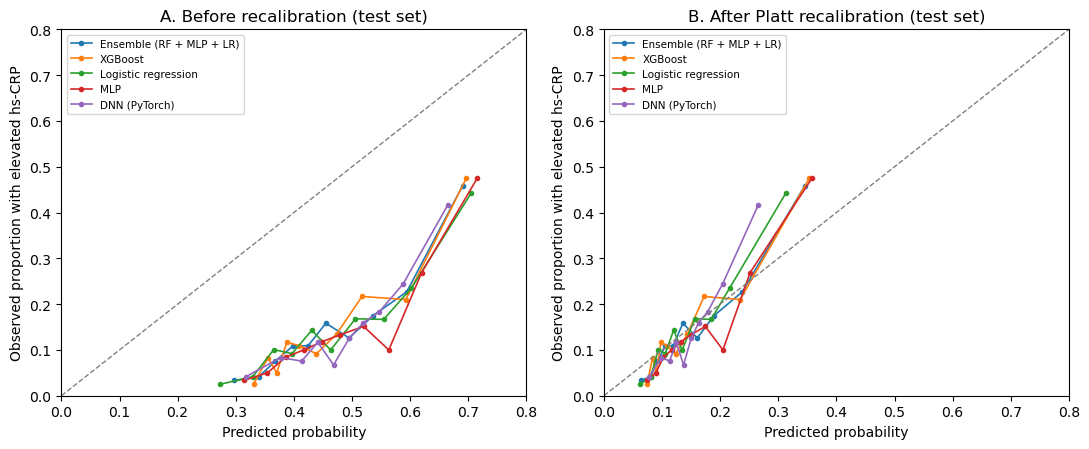

In [10]:
# Gambar suplemen: kalibrasi sebelum dan sesudah rekalibrasi Platt
show = [m for m in ['Ensemble (RF + MLP + LR)', 'XGBoost', 'Logistic regression', 'MLP', 'DNN (PyTorch)'] if m in cal_curves]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for a, v, tag in zip(ax, ['Uncalibrated', 'Platt'], 'AB'):
    for name in show:
        fr, mp = calibration_curve(y_te, cal_curves[name][v], n_bins=10, strategy='quantile')
        a.plot(mp, fr, marker='o', ms=3, lw=1.2, label=name)
    a.plot([0, 1], [0, 1], ls='--', c='grey', lw=1); a.set_xlim(0, 0.8); a.set_ylim(0, 0.8)
    a.set(xlabel='Predicted probability', ylabel='Observed proportion with elevated hs-CRP',
          title=f'{tag}. {"Before recalibration" if v == "Uncalibrated" else "After Platt recalibration"} (test set)')
    a.legend(fontsize=7.5, loc='upper left')
plt.tight_layout()
fig.savefig('figS1_recalibration.png', dpi=300, bbox_inches='tight')
fig.savefig('figS1_recalibration.tiff', dpi=600, bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})
plt.show()

## 4. Analisis sensitivitas
(a) CRP > 10 mg/L tetap disertakan · (b) model tanpa *kesehatan dirasa buruk* · (c) peserta yang dikeluarkan vs yang dianalisis

In [11]:
REF = 'XGBoost' if 'XGBoost' in MODELS else 'HistGB (pengganti XGBoost)'
def holdout_auc(Xd, yd, feats=FEATS, name=REF):
    a, b, ya, yb = train_test_split(Xd[feats], yd, test_size=0.2, stratify=yd, random_state=SEED)
    m = make_models(feats)[name].fit(a, ya); p = m.predict_proba(b)[:, 1]
    lo, hi = np.percentile([roc_auc_score(yb[i], p[i]) for i in
                            [np.random.default_rng(SEED + k).integers(0, len(yb), len(yb)) for k in range(1000)]
                            if yb[i].min() != yb[i].max()], [2.5, 97.5])
    return roc_auc_score(yb, p), lo, hi, len(yd), int(yd.sum())

sens_rows = []
auc, lo, hi, n, c = holdout_auc(X, y); sens_rows.append({'Analysis': 'Main model (CRP ≤10 mg/L)', 'n': n, 'cases': c, 'Test AUC': auc, '95% CI low': lo, '95% CI high': hi})
F_nosrh = [f for f in FEATS if f != 'srh_poor']
auc, lo, hi, n, c = holdout_auc(X, y, F_nosrh); sens_rows.append({'Analysis': 'Without poor self-rated health', 'n': n, 'cases': c, 'Test AUC': auc, '95% CI low': lo, '95% CI high': hi})

excluded = None
if os.path.exists(ANALYTIC_FILE):
    A = pd.read_csv(ANALYTIC_FILE, dtype={'pidlink': str, 'hhid14': str}, low_memory=False)
    CORE = ['age', 'female', 'educ', 'pce', 'smoke_status', 'bmi', 'sbp', 'pa_walk_days', 'n_chronic']
    base = A[(A.in_dbs == 1) & (A.age >= 15) & (A.pregnant != 1) & A.crp_plas_equi.notna()].copy()
    base['crp_high'] = (base.crp_plas_equi >= 3).astype(int)
    full = base.dropna(subset=CORE)                                     # CRP > 10 tetap disertakan
    auc, lo, hi, n, c = holdout_auc(full[FEATS], full.crp_high.values)
    sens_rows.append({'Analysis': 'CRP >10 mg/L included', 'n': n, 'cases': c, 'Test AUC': auc, '95% CI low': lo, '95% CI high': hi})
    # (c) perbandingan peserta dikeluarkan vs dianalisis
    base['group'] = np.select([base.crp_plas_equi > 10, base[CORE].isna().any(axis=1)],
                              ['Excluded: hs-CRP >10 mg/L', 'Excluded: missing core predictor'], 'Analysed')
    excluded = base.groupby('group').agg(n=('age', 'size'), age_mean=('age', 'mean'), female_pct=('female', lambda s: s.mean() * 100),
                                         urban_pct=('urban', lambda s: s.mean() * 100), bmi_mean=('bmi', 'mean'),
                                         current_smoking_pct=('smoke_status', lambda s: (s == 2).mean() * 100),
                                         crp_median=('crp_plas_equi', 'median')).round(2)
    display(excluded)
tab_sens = pd.DataFrame(sens_rows).round(3)
tab_sens

,n,age_mean,female_pct,urban_pct,bmi_mean,current_smoking_pct,crp_median
group,,,,,,,
Analysed,5980,41.79,54.06,57.79,23.00,31.00,0.69
Excluded: hs-CRP >10 mg/L,240,45.47,57.50,59.17,23.85,27.92,15.61
Excluded: missing core predictor,533,63.49,59.66,54.22,21.60,25.14,0.86


,Analysis,n,cases,Test AUC,95% CI low,95% CI high
0,Main model (CRP ≤10 mg/L),5980,904,0.729,0.687,0.766
1,Without poor self-rated health,5980,904,0.715,0.674,0.756
2,CRP >10 mg/L included,6199,1123,0.690,0.649,0.730


In [12]:
with pd.ExcelWriter('analisis_tambahan.xlsx') as xw:
    cv_summary.to_excel(xw, sheet_name='RepeatedCV_summary', index=False)
    cv_diff.to_excel(xw, sheet_name='RepeatedCV_vs_ensemble', index=False)
    cv_folds.to_excel(xw, sheet_name='RepeatedCV_folds', index=False)
    tab_cluster.to_excel(xw, sheet_name='Logit_clusterSE', index=False)
    tab_smoke_sex.to_excel(xw, sheet_name='Smoking_by_sex', index=False)
    tab_cal.to_excel(xw, sheet_name='Recalibration', index=False)
    tab_sens.to_excel(xw, sheet_name='Sensitivity', index=False)
    if excluded is not None: excluded.to_excel(xw, sheet_name='Excluded_vs_analysed')
    pd.DataFrame({'item': ['MODE', 'REPEATS', 'households', 'test participants sharing a household with training'],
                  'value': [MODE, REPEATS, n_hh, int(shared.sum())]}).to_excel(xw, sheet_name='Info', index=False)
print('Tersimpan: analisis_tambahan.xlsx + figS1_recalibration.png/.tiff | MODE =', MODE)

Tersimpan: analisis_tambahan.xlsx + figS1_recalibration.png/.tiff | MODE = FINAL
